<a href="https://colab.research.google.com/github/shitcodebykaushik/.github/blob/master/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# First code for the neural network
print("Welcome to the neural Network")
print("Handwritten Digit Classification with a Simple Neural Network ")

Welcome to the neural Network
Handwritten Digit Classification with a Simple Neural Network 


# Important
You cannot realistically train an LLM from scratch on a normal computer.
- LLMs are made using neural networks—the same concepts you’re learning now, just scaled up massively.
- An LLM is a very big neural network trained on a huge amount of text .
- A batch is the number of training example seen by the model before one update to its internall parametrs is performed .
- When we train a neural network we typically use an optimization algorithm like gradiant descent to adjust the models parameters (weight and biase)  to minimize the loss function .
- Processing th data in the small bat h is musch more memeory  efficiant thant trying to load the entire dataset into memory . It also allows for the parallelization sppending up training . And mini batched provide the good balance between the computaional efficiency of stochatic gradient descent (batch size of 1)  and the stability of batch gradiant descent (entire dataset)
- Paramets ar ethe weight and bias .


 A neural network is a computational model inspired  by the structure and the function of the human brain . At its core,its a sytem of interconnected nodes ,or neurons, that process and transmit information .
 # Key Components of the Neural Network
  - Neurons (Nodes) These are the  fundamental units of a neural network,similar to biological neurons. Each neuron receives input,processes it and then passes the output to the other neurons .
  - Connections (Synapses) Each neurons are connected to each other . Each connection has weight associated with it ,which determines the sterngth and improtance of the connection ,These weight are what the network learns during training .

  # Activation Function
  -  After neuron process its inputs an activation function determines wheather and to what extent that neuron send signal to the next layer . Common activation functions include ReLU, Sigmoid, and Tanh, which introduce non-linearity into the network, allowing it to learn complex patterns.
  # BIAS
  - A bias term is added to the weighted sum of inputs before the activation function is applied. It allows the activation function to be shifted, providing more flexibility for the network to model relationships.



In [ ]:
import tensorflow as tf
from tensorflow  import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
#Load the MNIST dataset
(x_train,y_train), (x_test,y_test) = keras.datasets.mnist.load_data ()

print(f'Original shape of the data: {x_train.shape}')
print(f'Original shape of the labels: {y_train.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Original shape of the data: (60000, 28, 28)
Original shape of the labels: (60000,)


In [ ]:
# NPZ is the binary format
# Normalize pixel values to 0-1 range
x_train = x_train.astype('float32')/255.0
x_test = x_test.astype('float32')/255.0


# Flatten the images:
x_train = x_train.reshape((-1,28*28))
x_test = x_test.reshape((-1,28*28))

# One-hot encode the labels

num_classes = 10
y_train = keras.utils.to_categorical(y_train,num_classes)
y_test = keras.utils.to_categorical(y_test,num_classes)


print(f'\n Shape of preprocessed training data: {x_train.shape}')
print(f"Shape of preprocessed training labels:{y_train.shape}")



 Shape of preprocessed training data: (60000, 784)
Shape of preprocessed training labels:(60000, 10)


In [ ]:
# This now where we are building  Neural Netowrk Model  And  here we are defining the architecture of our neural network
model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128,activation='relu'),
    layers.Dense(64,activation='relu'),
    layers.Dense(num_classes,activation='softmax')
])

In [ ]:
# Compile the model Before training ,we need to compile  it as this is where we define the how the learning process will happen
# Optimizer : This algorith dicates how the model will uodate its weights and biases based to the calculated error . `adam` is very popular and effective choice .
# Loss Function : A function that measure how wrong the model predictions are compared to the actual labels . For multi-class classsification with one-hot encoded labels
# Metrics : What to monitor during training and testing

model.compile (
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
# Train the model  using fit() method . This is where  the iteartive process of forward propgation,loss calculation,backpropagation and weight update happens.
# Epochs means how many time the model will go throuugh the entire training dataset . More epochs can led to better learning .
epochs = 10
batch_size =32
print("\n Starting model training....")
history = model.fit(
    x_train,y_train,
    batch_size=batch_size,
    validation_split=0.1,
    verbose=0
)

print("Model training complete.... ")



 Starting model training....
Model training complete.... 


In [ ]:
loss,accuracy = model.evaluate (x_test,y_test,verbose=0)
print(f'\n Test Loss: {loss:.4f}')
print(f'\n Test Accuracy: {accuracy:.4f}')
predictions = model.predict(x_test)

print("\n Sample Predictions (actual output would be array of probabilities):")
for i in range (5):
  predicted_class = np.argmax(predictions[i])
  actual_class = np.argmax(y_test[i])
  print(f'Predicted: {predicted_class}, Actual: {actual_class}')


 Test Loss: 0.1344

 Test Accuracy: 0.9590
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

 Sample Predictions (actual output would be array of probabilities):
Predicted: 7, Actual: 7
Predicted: 2, Actual: 2
Predicted: 1, Actual: 1
Predicted: 0, Actual: 0
Predicted: 4, Actual: 4


# Final Note :- This was the first complete work

# Day 1
- Foundation for the neural networks
- Learn to write clean,effcient,NN-ready code

In [ ]:
# Implement a Single Neuron
import  numpy as np
def relu (z):
  return np.maximum(0,z)

def neuron (x,w,b,activation):
  z=np.dot(w,x)+b
  return activation(z)

x = np.array([1.0,2.0])
w = np.array([0.5,-0.3])
b =0.1

output = neuron(x,w,b,relu)
output

np.float64(2.7755575615628914e-17)

In [ ]:
# Designing the single neuron
input = [1,2,3]
input2 = [0.2,0.8,-0.5]
bias = 2
output = (input[0]*input2[0]+input[1]*input2[1]+input[2]*input2[2]+bias)

print(output)


2.3


In [ ]:
# LAyers of Neurons are nothing but te groups of the neurons. Each neuron in a layer tales exactly the same input - the input give to the layer
# The layers output is a set of these outputs one per each neuron .
# Weight adn the bias make the neuron


In [ ]:
# Test 1 Sigmoid
def sigmoid(z) :
  return 1/(1+np.exp(-z))


print( neuron(x,w,b,sigmoid))

0.5


In [ ]:
# Broadcasting
import numpy as np
A = np.array([1,2,3])
B = 10
print(B+A)

# Here  10 is  broadcast to [10,10,10]

[11 12 13]


In [ ]:
!pip install nnfs


# Using the nnfs pip lib
- This is the support library  which helps to build neural network from scratch using the pure python and  numpy while avoiding the repeative code setup .

- nnfs.init() does three things:it sets the random seed to 0 by default creates float32 dtype defualt and override the original dot product from numpy .



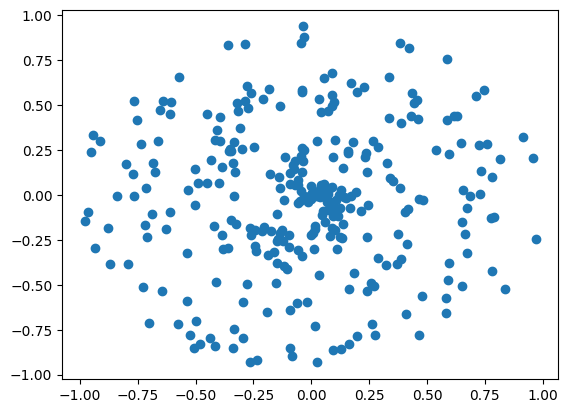

In [ ]:
import numpy as np
from nnfs.datasets import spiral_data
import nnfs
nnfs.init()
import matplotlib.pyplot as plt
x,y = spiral_data(samples=100,classes = 3)
plt.scatter(x[:,0],x[:,1])
plt.show()

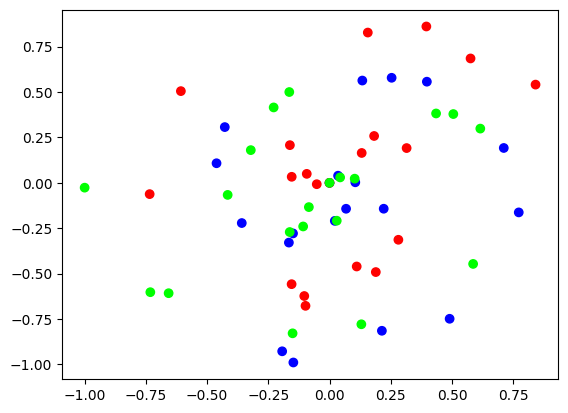

In [ ]:
import numpy as np
from nnfs.datasets import spiral_data
import nnfs
nnfs.init()
import matplotlib.pyplot as plt  # This library is used to draw graphs and plots
x,y = spiral_data(samples=20,classes = 3)  # x is input data (corrdinated of points ) y is the the lable (which class each points belong to )specifically 100 points per class so here we have 3 class total 300
plt.scatter(x[:,0],x[:,1],c=y,cmap='brg')  # This draw a colored scatter plot of the data
plt.show()  # Display the graph on the screen

# Tip
- Remember that neural network will not be aware of the color difference as the data have no class encdoing.

# Dense layer
- A dense layer means fully connected ,Every input is connected to every neuron in the next layer . Think of it like inputs = studens and neuron is teacher  . Every studented talks to every teacher ,tha why its call fully connected.
- The qs is why do we need  a layer_dense class the answer is that we create class that stored the weight and biases knows how to calculate output .This makes the code reusuable ,cleaner and more relaistic
- Weights decides how important each input is . If all weight were the same then all neurons would learn the same things and the network would be useless . Random weight  means neuorns learn different patterns .
- `Forward` This runs every time data passes through the layer . Inputs gors in then the output comes out and inside the this function we calcualte the  `output = inouts.weights+biases` .
- Small random weights ans zero biases help neurons stay alive and allow the network to lean .
- Large weights will make the neuron to fire too hard and it will become dead neurons .


# Step function
- It means reminder
- If the input>=threshold then output is 1
- If the input < threshold then the output is 0 .
- So neuron either fires (1) or does nothing (0)

- If the neuorn output is zero for every input then its problem ,it means that neuron is dead . And then the chain reaction begin so it means the one nrueon is zero then the nex recive s the smae and it conitnue, this makes the network non-trainable .

# np.random.randn
- The following things this does
  - Geneartates random numbers
  - Both positive and negative
  - Centred around  0
- This follows a Gaussian  (bell curve) distribution .

- Neural network learn best when values are roughly between `-1 and +1`  .

 # Why multiply with the 0.01
 - As it makes the weight  small  output . neurons activate gradually  learning is smoother . fewer dead neurons .

# Why np.zeros for biases
- Start neutral and dont dominate the output ,let the learning decide their value . Biases help neurons activate .




In [ ]:
import numpy as np
import nnfs
nnfs.init()
print(np.zeros((2,5)))

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


In [ ]:
import numpy as np
import nnfs
nnfs.init()
print(np.random.randn(3,5))

[[ 1.7640524   0.4001572   0.978738    2.2408931   1.867558  ]
 [-0.9772779   0.95008844 -0.1513572  -0.10321885  0.41059852]
 [ 0.14404356  1.4542735   0.7610377   0.12167501  0.44386324]]


In [ ]:
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()

# Dense layer
class Layer_Dense:
    # Layer initialization
    def __init__(self, n_inputs, n_neurons):
        # Initialize weights and biases
        self.weights = 0.01 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

    # Forward pass
    def forward(self, inputs):
        # Calculate output values from inputs, weights, and biases
        self.output = np.dot(inputs, self.weights) + self.biases

# Creating the dataset (outside the class definition)
x, y = spiral_data(samples=100, classes=3)

# Create Dense layer with 2 input features and 3 output values
dense1 = Layer_Dense(2, 3)

# Perform a forward pass of our training data through this layer
dense1.forward(x)

# Lets see output of the first few samples
print(dense1.output[:50])

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-1.04751882e-04  1.13953611e-04 -4.79834998e-05]
 [-2.74148420e-04  3.17291502e-04 -8.69217984e-05]
 [-4.21883655e-04  5.26662567e-04 -5.59126820e-05]
 [-5.77076804e-04  7.14014051e-04 -8.94304394e-05]
 [-3.54306976e-04  3.50254879e-04 -2.33634812e-04]
 [-8.92670010e-04  1.07678759e-03 -1.94532375e-04]
 [-9.33507807e-04  1.07238023e-03 -3.12273973e-04]
 [-1.12437585e-03  1.31128007e-03 -3.36296740e-04]
 [-1.33869553e-03  1.62009057e-03 -2.81017943e-04]
 [-1.48779724e-03  1.79484230e-03 -3.23859538e-04]
 [-1.20035873e-03  1.58119109e-03  8.65937000e-06]
 [-1.56528328e-03  1.99173321e-03 -1.30997345e-04]
 [-1.85718178e-03  2.30642664e-03 -2.70479388e-04]
 [-1.78093580e-03  2.27836682e-03 -1.24245722e-04]
 [-1.85300526e-03  2.38476763e-03 -1.00471654e-04]
 [-6.99865050e-04  1.11472746e-03  3.96097894e-04]
 [-2.19024252e-03  2.79446482e-03 -1.68075712e-04]
 [-1.69829139e-03  2.29598465e-03  1.31671681e-04]
 [-2.60229013e-03  3.27291898e-

# Actiavation function
- A neuron first calculates `weights*inputs+bias` this give raw number, then activation function is applied after this to decide how much the neuron should activate and what value it should send forwared  . So overall activation function is decison maker of neuron . It modiefies the output of a neuron , Without this the NN will be always linear , and when we add this it become no-linear activation functions and now the network can bend line ,create curves and learn complex shapes . This is what allows neural networks to learn the non linear relationships .


# Sigmoid Activation Function
- The problem with the step function is that it gives only two outputs:-
 - 0(off)
 -1 (on)
 - On the otther hand sigmoid  activation function gives the Output between 0 and  1  which is smooth ,gradual change .
- The sigmoid is better beachuse it shows how confident the neuron is  and the output close to 0 means very unlikely and output close to 1 means very likely .

- Smooth imput change means small output change and optimeze can see direction and size of the change
- Works well with the probalities
- Sigmod fixed the learning problem of the step function by making the outputs continuons . Making the learning posssible with the gradiant based optimizer .



In [ ]:
import math
print (math.log(1.))
print (math.log(0.95))

# Categorical Cross Entropy Loss Class


0.0
-0.05129329438755058


# Transformer
- Previously models are based on complex recurrent or convolutional neural networks that include an encoder and a decoder .
- The transformer is totally based on the attention mechanism,dispensing with the recurrence and convoluions entirely .
- This model architecture eschewing recurrence and instead relying entirely on an attention mechanism to draw global global dependencies between input nd output . The transformer allows for more parallelization and can reach new state of the art in translation quality after being trained for as little as tweleve hours on eight P100 GPUs .
- To the best ,the transformer is the first transduction model relying entirelly on self-attention to compute representation of it input  and the output ,without using the sequence aligned RNNs or convolution .
# Architecutre
- Left side : Encoder  (Process input )
- Right side : Decoder (Geneareate output )

# Input Embedding
- Converts the input  tokens (words/subwords ) into numberical vectors .
- Each toker is 512 dimensional vector .
# Positional Encoding
- Critical innovation => Adds positional information since transformers process all tokedn simultaneously . And it used the sine/cosine function to encode position .



# Encoder
- Reads the entire input sequence at once,Create a contextual representation like memory or understanding .

- The encoder is composed of a stack of N =6 indentical layers .Each layer has two sub-layers . The first is multi-head self attention mechanism and the second is a simple position wise fully connected feed-forward network .

# New section